# Week 5 — Friends, foes and family

The Marvel network gets its text. For every link A → B we pull the sentence on
A's page where B is mentioned, label the link from the words around the name,
check those labels by reading them, and ask one question:

> **Do enemy links cross community boundaries more often than ally links?**

This notebook produces every number and figure in
[the week 5 post](../weeks/week5/week5.html). Preprocessing choices are stated
where they are made, because each one changes the answer.

In [1]:
import sys
sys.path.append("../src")

import re, csv
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score as nmi

import marvel
marvel.use_site_style()
STORY_C, META_C = "#D22B2B", "#3F6FB0"      # validated pair: CVD dE 20, both pass contrast

nodes = marvel.load_nodes()
edges = pd.read_csv(marvel.DATA / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
name = dict(zip(nodes.node_id, nodes.name))
desc = dict(zip(nodes.node_id, nodes.description.fillna("")))
pages = marvel.load_pages()
assert set(pages) == set(nodes.node_id), "every node should have exactly one page"
print(f"{len(pages)} pages, {sum(len(t) for t in pages.values()):,} characters, {len(edges)} directed links")

303 pages, 4,447,666 characters, 1784 directed links


## 1. Sentences

A rule-based splitter (`marvel.split_sentences`): paragraphs first, then split
after `. ! ?` when the next character starts a sentence, with abbreviations
(*No. 1*, *Vol. 2*) and initials (*U.S.A.*) protected. We chose it over a
downloaded model on purpose — it runs identically on every machine, and its
mistakes are visible in the code.

In [2]:
sents = {nid: marvel.split_sentences(t) for nid, t in pages.items()}
print(f"{sum(len(v) for v in sents.values()):,} sentences")
for s in sents["Rockman_(character)"][:3]:
    print("  -", s)

38,108 sentences
  - Rockman is a fictional superhero appearing in American comic books published by Marvel Comics.
  - The character first appeared in U.S.A. Comics No. 1 (August 1941), published by Marvel predecessor Timely Comics during the 1930s to 1940s period historians and fans call the Golden Age of Comics.
  - As credits were not routinely given in comic books of this period, his writer and artist co-creators are unknown, although the first page of his debut story was drawn by Charles Nicholas (itself a house pen name) and the remainder by Basil Wolverton.


## 2. Finding B on A's page

The plain text has lost the link markup, so a link can only be found by name.
Each character gets a small set of aliases:

- the page title without its disambiguator: *Hercules (Marvel Comics)* → *Hercules*
- the disambiguator, **only if it reads like a name** (every word capitalised):
  *Black Widow (Natasha Romanova)* → *Natasha Romanova*, but not *White Tiger
  (Heroes for Hire)* → ~~*Heroes for Hire*~~, which is a team
- the alter ego in the description: *The Abomination (Emil Blonsky) is…* → *Emil Blonsky*
- a quoted nickname: *Jonathan Lowell Spencer "Johnny" Storm* → *Johnny Storm*

Matching is case-sensitive and whole-word, with hyphens counted as part of the
word so *Hulk* does not match inside *She-Hulk*.

**The self-collision rule.** She-Hulk's page mentions *She-Hulk* 276 times, and
one of her links goes to *She-Hulk (Lyra)* — whose alias is also *She-Hulk*.
Any alias the target shares with the source page's own subject is dropped for
that link, or every sentence about Jennifer Walters counts as a sentence about Lyra.

In [3]:
GENERIC = {"character", "comics", "marvel comics", "marvel", "characters", "morituri",
           "earth-616", "ultimate marvel", "marvel cinematic universe"}

def aliases(nid):
    nm, out = name[nid], set()
    base = re.sub(r"\s*\(.*?\)\s*$", "", nm).strip()
    if base:
        out.add(base)
    m = re.search(r"\((.*?)\)\s*$", nm)
    if m and m.group(1).lower() not in GENERIC and all(w[:1].isupper() for w in m.group(1).split()):
        out.add(m.group(1).strip())
    m = re.match(r"^[^(]{0,60}\(([^)]+)\)", desc[nid])
    if m:
        for part in re.split(r",|;| alias | also known as ", m.group(1)):
            part = part.strip()
            if len(part.split()) >= 2 and part[0].isupper() and part.lower() not in GENERIC:
                out.add(part)
    for a in list(out):
        if a.startswith("The "):
            out.add(a[4:])
    extra = set()
    for a in out:
        q = re.search(r'"([^"]+)"\s+(\w[\w-]*)$', a)
        if q:
            extra.add(f"{q.group(1)} {q.group(2)}")
    return sorted((out | extra) - {a for a in out if '"' in a}, key=len, reverse=True)

AL = {nid: aliases(nid) for nid in name}
for who in ["Abomination_(character)", "Black_Widow_(Natasha_Romanova)", "Human_Torch",
            "White_Tiger_(Heroes_for_Hire)", "She-Hulk_(Lyra)"]:
    print(f"  {name[who]:<34} {AL[who]}")

def target_pattern(src, tgt):
    use = [a for a in AL[tgt] if a not in set(AL[src])]      # the self-collision rule
    if not use:
        return None
    return re.compile(r"(?<![\w-])(" + "|".join(re.escape(a) for a in use) + r")(?![\w-])")

  Abomination (character)            ['Emil Blonsky', 'Abomination']
  Black Widow (Natasha Romanova)     ['Natasha Romanova', 'Black Widow']
  Human Torch                        ['Johnny Storm', 'Human Torch']
  White Tiger (Heroes for Hire)      ['White Tiger']
  She-Hulk (Lyra)                    ['She-Hulk', 'Lyra']


## 3. Labelling a link from the words around the name

Six word lists: five story relations and one for publication context
(*appears in*, *debuted*, *voiced by*, *issue*…), because plenty of links are
nothing but "Star-Lord appears in *Ultimate Spider-Man*".

Two rules decide which keyword belongs to which character. Both were added after
reading the output (section 4):

1. **The nearest keyword wins.** Within ten words of the name, the closest
   keyword decides — so *fought **alongside** Wolverine* makes Wolverine an ally.
   An earlier version used a fixed priority and labelled him an enemy.
2. **A keyword belongs to the character mentioned nearest to it.** In *her former
   **husband** Black Panther, Luke Cage and Misty Knight*, the husband is Black
   Panther, not Misty Knight.

*clone* was removed from the family list after it turned out to mean *Nazi clone*.

In [4]:
CLASSES = {
  "family":  r"son|sons|daughter|daughters|father|mother|brother|brothers|sister|sisters|sibling|siblings|"
             r"cousin|uncle|aunt|niece|nephew|parent|parents|grandfather|grandmother|twin|"
             r"stepfather|stepmother|half-brother|half-sister|granddaughter|grandson",
  "romance": r"love|lover|loves|loved|dated|dating|girlfriend|boyfriend|kiss|kissed|kisses|romance|"
             r"romantic|romantically|married|marry|marries|marriage|wife|husband|fianc[ée]e?|affair|crush|wedding",
  "enemy":   r"enemy|enemies|nemesis|foe|foes|archenemy|arch-enemy|archnemesis|rival|rivals|fight|fights|"
             r"fought|fighting|battle|battles|battled|battling|defeat|defeats|defeated|kill|kills|killed|"
             r"murder|murders|murdered|attack|attacks|attacked|kidnap|kidnaps|kidnapped|captured|captures|"
             r"imprisoned|betrayed|betrays|opposes|opposed|confronts|confronted|duel|hunted|hunts",
  "ally":    r"ally|allies|allied|alongside|help|helps|helped|helping|aid|aided|assist|assists|assisted|"
             r"partner|partners|partnered|friend|friends|friendship|rescue|rescues|rescued|save|saves|saved|"
             r"befriend|befriends|befriended|mentor|mentored|mentors|trained|trains|sidekick|protege|protégé",
  "team":    r"member|members|membership|joined|joins|join|teammate|teammates|recruited|recruits|recruit|"
             r"founding|roster|squad|founded|co-founded|reserve",
  "media":   r"appears|appeared|appearance|appearances|voiced|portrayed|film|films|movie|series|issue|issues|"
             r"comic|published|debut|debuted|created|creator|creators|writer|artist|game|animated|"
             r"television|miniseries|storyline|crossover|title|edition|cover|episode|adaptation|volume|"
             r"one-shot|limited",
}
STORY = ["family", "romance", "enemy", "ally", "team"]       # tie-break order
ORDER = STORY + ["media"]
WINDOW = 10
KW  = {k: re.compile(r"^(?:" + v + r")$", re.I) for k, v in CLASSES.items()}
TOK = re.compile(r"[\w][\w'’-]*")
ANYCHAR = re.compile(r"(?<![\w-])(" + "|".join(
    re.escape(a) for a in sorted({a for v in AL.values() for a in v}, key=len, reverse=True)) + r")(?![\w-])")

def token_class(toks, i):
    w = toks[i][2]
    nxt = toks[i + 1][2].lower() if i + 1 < len(toks) else ""
    if re.match(r"^team(s|ed|ing)?$", w, re.I) and nxt == "up":
        return "ally"                                        # "team up" is an alliance, not a team
    if re.match(r"^join(s|ed)?$", w, re.I) and nxt == "forces":
        return "ally"
    return next((k for k in ORDER if KW[k].match(w)), None)

def _span(toks, s0, e0):
    idx = [i for i, (a, b, _) in enumerate(toks) if a >= s0 and b <= e0]
    return (idx[0], idx[-1]) if idx else None

def _gap(i, rng):
    lo, hi = rng
    return lo - i if i < lo else (i - hi if i > hi else 0)

def mention_labels(sentence, tpat):
    toks = [(m.start(), m.end(), m.group()) for m in TOK.finditer(sentence)]
    targets = [r for r in (_span(toks, *m.span()) for m in tpat.finditer(sentence)) if r]
    others = [r for r in (_span(toks, *m.span()) for m in ANYCHAR.finditer(sentence))
              if r and not any(r[0] <= t[1] and t[0] <= r[1] for t in targets)]
    out = []
    for tr in targets:
        best = None
        for i in range(max(0, tr[0] - WINDOW), min(len(toks), tr[1] + WINDOW + 1)):
            if tr[0] <= i <= tr[1]:
                continue
            k = token_class(toks, i)
            if k is None:
                continue
            d = _gap(i, tr)
            if others and min(_gap(i, o) for o in others) < d:
                continue                                     # the keyword is someone else's
            if best is None or (d, ORDER.index(k)) < best[0]:
                best = ((d, ORDER.index(k)), k)
        out.append(best[1] if best else None)
    return out

def label_of(hits):
    story = {k: hits.get(k, 0) for k in STORY if hits.get(k, 0) > 0}
    if story:
        top = max(story.values())
        return next(k for k in STORY if story.get(k) == top)
    return "media" if hits.get("media", 0) else "unlabelled"

In [5]:
typed = []
for s, t in edges.itertuples(index=False):
    tp = target_pattern(s, t)
    found = [x for x in sents[s] if tp and tp.search(x)]
    hits, per = Counter(), []
    for x in found:
        h = Counter(k for k in mention_labels(x, tp) if k)
        hits += h
        per.append((x, label_of(h)))
    typed.append(dict(source=s, target=t, n=len(found), hits=hits,
                      label=label_of(hits) if found else "no sentence", sentences=per))

n_found = sum(1 for e in typed if e["n"])
print(f"links with at least one sentence: {n_found}/{len(typed)} ({n_found/len(typed):.1%})")
for k, v in Counter(e["label"] for e in typed).most_common():
    print(f"   {k:<12} {v:>5}  {v/len(typed):6.1%}")

links with at least one sentence: 1569/1784 (87.9%)
   unlabelled     600   33.6%
   enemy          321   18.0%
   ally           219   12.3%
   no sentence    215   12.1%
   media          159    8.9%
   team           106    5.9%
   family         106    5.9%
   romance         58    3.3%


## 4. Reading the labels

A keyword classifier always produces an answer. Whether the answer is right is
a question about the text, so we read a random sample and graded each label
against one rule: **correct only if the sentence puts the target in that
relationship with the source page's own subject.**

Two rounds, stored in `data/derived/week5_validation.tsv` with a reason for every
error. Round 1 graded the first version of the labeller; its failures produced
the fixes in section 3; round 2 graded **fresh** links under the fixed version,
because re-grading the same links would flatter the fix.

In [6]:
V = pd.read_csv(marvel.DATA / "derived" / "week5_validation.tsv", sep="\t", comment="#").fillna("")
lab_now = {(e["source"], e["target"]): e["label"] for e in typed}

r2 = V[V["round"] == 2]
same = sum(lab_now[(r.source, r.target)] == r.label for r in r2.itertuples())
assert same == len(r2), "round 2 was graded on exactly this labeller - labels must reproduce"
print(f"round 2: all {len(r2)} graded labels reproduce under the current labeller")
r1 = V[V["round"] == 1]
kept = sum(lab_now[(r.source, r.target)] == r.label for r in r1.itertuples())
print(f"round 1: {kept}/{len(r1)} of the v1 labels survive the fixes unchanged\n")

prec = {}
print(f"{'label':<9}{'round 1':>9}{'round 2':>9}{'pooled':>9}   95% interval")
for k in ["enemy", "ally", "team", "romance", "family", "media"]:
    a = V[V.label == k]
    k1, n1 = a[a["round"] == 1].correct.sum(), (a["round"] == 1).sum()
    k2, n2 = a[a["round"] == 2].correct.sum(), (a["round"] == 2).sum()
    kk, nn = a.correct.sum(), len(a)
    lo, hi = marvel.wilson(kk, nn)
    prec[k] = (kk, nn, lo, hi)
    r2s = f"{k2}/{n2}" if n2 else "-"
    print(f"{k:<9}{f'{k1}/{n1}':>9}{r2s:>9}{kk/nn:>9.0%}   {lo:.0%}-{hi:.0%}")

round 2: all 56 graded labels reproduce under the current labeller
round 1: 52/68 of the v1 labels survive the fixes unchanged

label      round 1  round 2   pooled   95% interval
enemy        11/12     7/10      82%   61%-93%
ally         11/12     7/10      82%   61%-93%
team          8/12     8/12      67%   47%-82%
romance       6/12     8/12      58%   39%-76%
family        6/12     6/12      50%   31%-69%
media          7/8        -      88%   53%-98%


In [7]:
print("why the family label fails - every family error, in the grader's words:\n")
for r in V[(V.label == "family") & (V.correct == 0)].itertuples():
    print(f"  {name[r.source]} -> {name[r.target]}:  {r.why_wrong}")

why the family label fails - every family error, in the grader's words:

  Scarlet Witch -> Jericho Drumm:  'brother' is Jericho Drumm's own brother, not the Scarlet Witch's
  Ghost Rider -> Ghost Rider (Danny Ketch):  mother of Blaze and Ketch - kinship between them, not with the page's subject
  Frankenstein's Monster (Marvel Comics) -> Bucky (Marvel Comics):  'Nazi clone' - an enemy, not a relative
  Frankenstein's Monster (Marvel Comics) -> Human Torch (android):  'Nazi clone' - an enemy, not a relative
  Adam Warlock -> Black Widow (Natasha Romanova):  'Black Widow's clone' in a list of recruits
  Adam Warlock -> Doctor Strange:  same sentence - 'clone' again
  Patsy Walker -> Kristoff Vernard:  'the son of Doctor Doom'
  Spider-Woman -> Mayday Parker:  'Peter and MJ's daughter'
  White Tiger (comics) -> Black Panther (character):  'Sal's son'
  Bill Foster (character) -> Black Panther (character):  'Bill's nephew'
  Blade (character) -> Morbius:  'Midnight Sons' is a publishing i

Enemy and ally hold up at about 82%. Family is a coin flip, and the fixes did
not move it: kinship words attach to whoever sits in the possessive — *Sal's
son*, *Bill's nephew*, *the son of Doctor Doom* — and a keyword window cannot
see possession. So **the community test uses only enemy and ally.** The other
labels are reported, and flagged.

## 5. The question: do enemies cross community lines?

Communities from Louvain on the undirected giant component (277 characters,
1,421 links). One label per **pair** — the mention labels from both directions
pooled — so a reciprocated link is not counted twice.

Week 4 taught us one Louvain run is one sample, so everything is repeated over
ten seeds.

In [8]:
D = marvel.load_graph()
GC = marvel.giant_component(D)
deg = dict(GC.degree())
pair_hits, pair_n = {}, Counter()
for e in typed:
    p = frozenset((e["source"], e["target"]))
    pair_hits.setdefault(p, Counter()).update(e["hits"])
    pair_n[p] += e["n"]
pairs = [tuple(e) for e in GC.edges()]
lab = np.array([label_of(pair_hits[frozenset(p)]) if pair_n[frozenset(p)] else "no sentence"
                for p in pairs])
print(Counter(lab).most_common())

runs = [nx.community.louvain_communities(GC, seed=s) for s in range(10)]
cids = [{v: i for i, c in enumerate(r) for v in c} for r in runs]
order = list(GC)
agree = [nmi([cids[a][v] for v in order], [cids[b][v] for v in order])
         for a in range(10) for b in range(a + 1, 10)]
print(f"\n10 seeds: {sorted({len(r) for r in runs})} communities, NMI between runs {min(agree):.2f}-{max(agree):.2f}")
print("seed 0, named by highest-degree members:")
for c in sorted(runs[0], key=len, reverse=True):
    print(f"   {len(c):>3}  " + ", ".join(name[v] for v in sorted(c, key=lambda v: -deg[v])[:4]))

[(np.str_('unlabelled'), 463), (np.str_('enemy'), 289), (np.str_('ally'), 193), (np.str_('no sentence'), 142), (np.str_('media'), 127), (np.str_('team'), 87), (np.str_('family'), 80), (np.str_('romance'), 40)]



10 seeds: [7, 8, 9] communities, NMI between runs 0.53-0.89
seed 0, named by highest-degree members:
    48  Spider-Man, Venom (character), Black Cat (Marvel Comics), Black Widow (Natasha Romanova)
    43  Wolverine (character), Phoenix (Guardians of the Galaxy), Scarlet Witch, Betsy Braddock
    39  Hercules (Marvel Comics), Adam Warlock, Quasar (character), Nova (Richard Rider)
    35  Doctor Strange, Deadpool, Moon Knight, Ghost Rider
    31  Cloak and Dagger (characters), Deathlok, Black Bolt, Human Torch
    30  U.S. Agent, Human Torch (android), Bucky (Marvel Comics), Brian Braddock
    29  Hulk, She-Hulk, Hank Pym, Mockingbird (Marvel Comics)
    22  Black Panther (character), Luke Cage, Iron Fist (character), Misty Knight


In [9]:
CROSS = np.array([[cid[a] != cid[b] for a, b in pairs] for cid in cids])   # seeds x pairs
ROWS = ["enemy", "ally", "team", "family", "romance", "media", "unlabelled", "no sentence"]
print(f"{'label':<13}{'n':>5}   cross share, mean over seeds (range)")
print(f"{'ALL LINKS':<13}{len(pairs):>5}   {CROSS.mean():.3f}")
for k in ROWS:
    m = lab == k
    per_seed = CROSS[:, m].mean(1)
    print(f"{k:<13}{m.sum():>5}   {per_seed.mean():.3f}  ({per_seed.min():.3f}-{per_seed.max():.3f})")

label            n   cross share, mean over seeds (range)
ALL LINKS     1421   0.472
enemy          289   0.436  (0.422-0.467)
ally           193   0.410  (0.394-0.430)
team            87   0.422  (0.391-0.448)
family          80   0.255  (0.212-0.312)
romance         40   0.312  (0.275-0.425)
media          127   0.551  (0.520-0.583)
unlabelled     463   0.539  (0.512-0.564)
no sentence    142   0.537  (0.493-0.585)


### The permutation test

Shuffle the enemy/ally labels among the enemy and ally links and recompute the
difference. The stricter version shuffles only **within bins of hub-size** (the
larger endpoint degree, in quartiles), so a difference cannot come from enemies
simply attaching to bigger hubs.

In [10]:
rng = np.random.default_rng(0)
hub = np.array([max(deg[a], deg[b]) for a, b in pairs])

def strat_bins(mask, q):
    return np.digitize(hub[mask], np.quantile(hub[mask], q))

def perm_test(is_a, mask, cross, bins, n):
    g, c = is_a[mask], cross[mask]
    real = c[g].mean() - c[~g].mean()
    null = np.empty(n)
    for i in range(n):
        q = g.copy()
        for b in np.unique(bins):
            idx = np.where(bins == b)[0]
            q[idx] = rng.permutation(g[idx])
        null[i] = c[q].mean() - c[~q].mean()
    return real, (1 + np.sum(np.abs(null) >= abs(real))) / (1 + n), null

ea = np.isin(lab, ["enemy", "ally"])
enemy = lab == "enemy"
b_ea = strat_bins(ea, [.25, .5, .75])
print(f"median hub-size: enemy links {np.median(hub[enemy]):.0f}, ally links {np.median(hub[lab=='ally']):.0f}\n")
print("seed  enemy   ally   diff    p (hub-stratified)")
EA = []
for s in range(10):
    real, p, null = perm_test(enemy, ea, CROSS[s], b_ea, 10000 if s == 0 else 2000)
    EA.append((real, p))
    if s == 0:
        null_ea = null
    print(f"  {s}   {CROSS[s][enemy].mean():.3f}  {CROSS[s][lab=='ally'].mean():.3f}  {real:+.3f}   {p:.3f}")
print(f"\nbiggest difference we could have missed: 95% of shuffles stay within "
      f"±{np.quantile(np.abs(null_ea), .95):.3f}")

median hub-size: enemy links 27, ally links 27

seed  enemy   ally   diff    p (hub-stratified)


  0   0.433  0.409  +0.023   0.662
  1   0.426  0.394  +0.032   0.488


  2   0.446  0.430  +0.016   0.774
  3   0.429  0.399  +0.030   0.572


  4   0.433  0.425  +0.008   0.934
  5   0.467  0.394  +0.073   0.142


  6   0.426  0.399  +0.027   0.611
  7   0.422  0.409  +0.013   0.855


  8   0.433  0.420  +0.013   0.847
  9   0.446  0.420  +0.027   0.610

biggest difference we could have missed: 95% of shuffles stay within ±0.092


**No.** Enemy links cross community lines about as often as ally links, on
every seed. And the null has teeth: a difference of about nine points would
have shown up; we see two or three.

The same table shows what *does* separate: every story label crosses **less**
than the average link, and the links that are only publication context cross
**more**. Testing that directly, with the same hub-stratified shuffle:

In [11]:
story = np.isin(lab, STORY)
media = lab == "media"
b_all = strat_bins(np.ones(len(pairs), bool), [.2, .4, .6, .8])
b_sm = strat_bins(story | media, [.2, .4, .6, .8])
print("seed  story  not-story  diff    p     | story  media   diff    p")
SN, SM = [], []
for s in range(10):
    r1, p1, _ = perm_test(story, np.ones(len(pairs), bool), CROSS[s], b_all, 5000 if s == 0 else 1000)
    r2, p2, _ = perm_test(story, story | media, CROSS[s], b_sm, 5000 if s == 0 else 1000)
    SN.append((r1, p1)); SM.append((r2, p2))
    print(f"  {s}   {CROSS[s][story].mean():.3f}  {CROSS[s][~story].mean():.3f}     {r1:+.3f}  {p1:.4f} |"
          f" {CROSS[s][story].mean():.3f}  {CROSS[s][media].mean():.3f}  {r2:+.3f}  {p2:.4f}")

seed  story  not-story  diff    p     | story  media   diff    p


  0   0.405  0.549     -0.144  0.0002 | 0.405  0.520  -0.115  0.0210


  1   0.390  0.540     -0.149  0.0010 | 0.390  0.535  -0.145  0.0050


  2   0.408  0.561     -0.154  0.0010 | 0.408  0.583  -0.175  0.0010


  3   0.395  0.538     -0.143  0.0010 | 0.395  0.535  -0.141  0.0060


...

  5   0.403  0.512     -0.109  0.0010 | 0.403  0.535  -0.132  0.0090


  6   0.389  0.536     -0.147  0.0010 | 0.389  0.559  -0.170  0.0010


  7   0.395  0.537     -0.142  0.0010 | 0.395  0.567  -0.172  0.0010


  8   0.402  0.537     -0.135  0.0010 | 0.402  0.559  -0.157  0.0040


  9   0.406  0.560     -0.154  0.0010 | 0.406  0.567  -0.161  0.0030


## 6. Figures

wrote weeks/week5/figures/crossing.svg


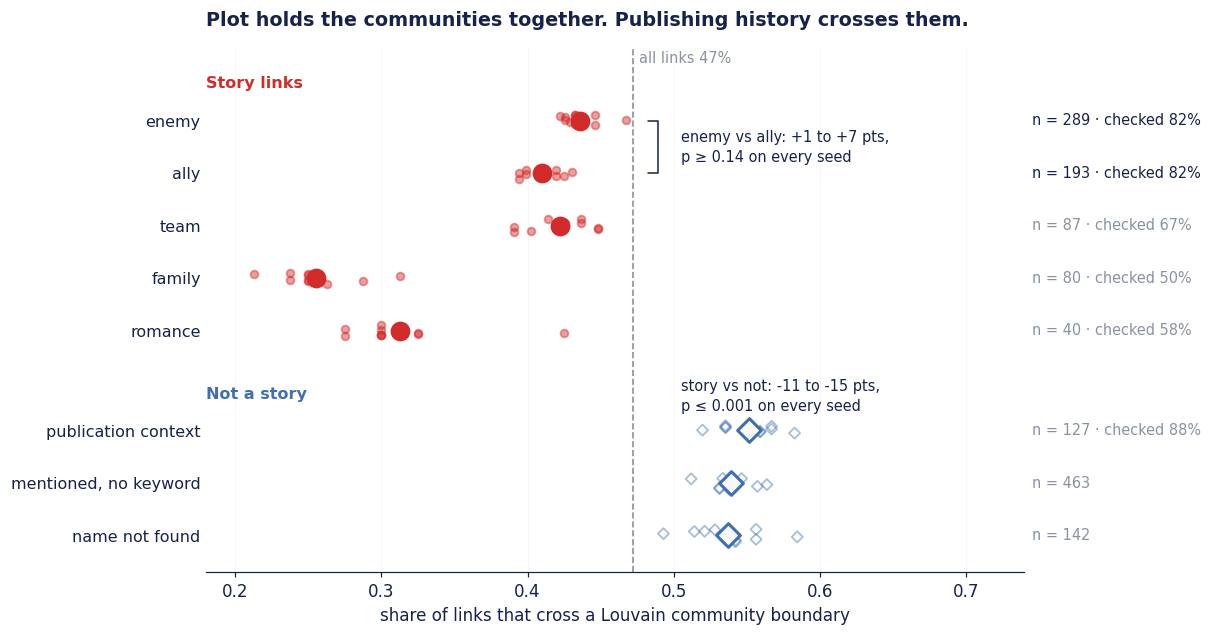

In [12]:
fig, ax = plt.subplots(figsize=(9.6, 6.2))
disp = {"enemy": "enemy", "ally": "ally", "team": "team", "family": "family", "romance": "romance",
        "media": "publication context", "unlabelled": "mentioned, no keyword", "no sentence": "name not found"}
ypos = {"enemy": 0, "ally": 1, "team": 2, "family": 3, "romance": 4,
        "media": 5.9, "unlabelled": 6.9, "no sentence": 7.9}
base = CROSS.mean()
ax.axvline(base, color=marvel.MUTED, ls="--", lw=1.1, zorder=1)
ax.text(base + .004, -1.05, f"all links {base:.0%}", color=marvel.MUTED, fontsize=9.5, va="bottom")
jit = np.random.default_rng(3)
for k in ROWS:
    y, m = ypos[k], lab == k
    vals = CROSS[:, m].mean(1)
    is_story = k in STORY
    col, mk = (STORY_C, "o") if is_story else (META_C, "D")
    ax.scatter(vals, y + jit.uniform(-.13, .13, len(vals)), s=26, marker=mk, alpha=.45,
               facecolors=col if is_story else "none", edgecolors=col, linewidths=1.2, zorder=3)
    ax.scatter([vals.mean()], [y], s=120, marker=mk, facecolors=col if is_story else marvel.CARD,
               edgecolors=col, linewidths=2, zorder=4)
    note = f"n = {m.sum()}"
    if k in prec:
        note += f" · checked {prec[k][0]/prec[k][1]:.0%}"
    ax.text(.745, y, note, va="center", fontsize=9.5, color=marvel.INK if k in ("enemy", "ally") else marvel.MUTED)
ax.set_yticks([ypos[k] for k in ROWS]); ax.set_yticklabels([disp[k] for k in ROWS], fontsize=10.5)
ax.set_ylim(8.6, -1.4); ax.set_xlim(.18, .74)
ax.text(.18, -.62, "Story links", fontsize=10.5, fontweight="bold", color=STORY_C, ha="left")
ax.text(.18, 5.3, "Not a story", fontsize=10.5, fontweight="bold", color=META_C, ha="left")
ax.annotate("", xy=(.48, 0), xytext=(.48, 1),
            arrowprops=dict(arrowstyle="-", color=marvel.INK, lw=1, connectionstyle="bar,fraction=.25"))
ax.text(.505, .5, f"enemy vs ally: {min(r for r, _ in EA)*100:+.0f} to {max(r for r, _ in EA)*100:+.0f} pts,\n"
        f"p ≥ {min(p for _, p in EA):.2f} on every seed", va="center", fontsize=9.5, color=marvel.INK, linespacing=1.4)
ax.text(.505, 5.25, f"story vs not: {max(r for r, _ in SN)*100:+.0f} to {min(r for r, _ in SN)*100:+.0f} pts,\n"
        f"p ≤ {max(p for _, p in SN):.3f} on every seed", va="center", fontsize=9.5, color=marvel.INK, linespacing=1.4)
ax.set_xlabel("share of links that cross a Louvain community boundary")
ax.set_title("Plot holds the communities together. Publishing history crosses them.",
             loc="left", fontsize=12.5, fontweight="bold", pad=14)
ax.grid(alpha=.15, color=marvel.RULE, axis="x"); ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
marvel.save(fig, 5, "crossing")
plt.show()

wrote weeks/week5/figures/validation.svg


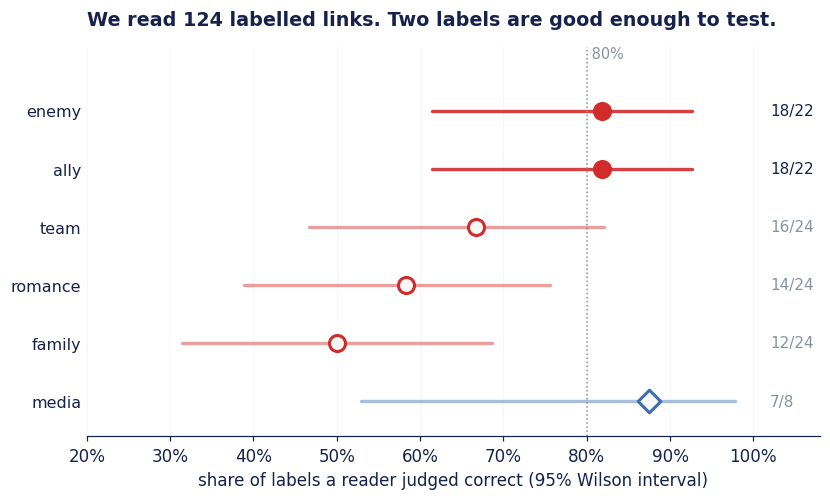

In [13]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
rows = ["enemy", "ally", "team", "romance", "family", "media"]
for y, k in enumerate(rows):
    kk, nn, lo, hi = prec[k]
    is_story = k in STORY
    col, mk = (STORY_C, "o") if is_story else (META_C, "D")
    used = k in ("enemy", "ally")
    ax.plot([lo, hi], [y, y], color=col, lw=2.2, alpha=.9 if used else .45, solid_capstyle="round")
    ax.scatter([kk / nn], [y], s=110, marker=mk, zorder=4, linewidths=2, edgecolors=col,
               facecolors=col if (is_story and used) else marvel.CARD)
    ax.text(1.02, y, f"{kk}/{nn}", va="center", fontsize=10, color=marvel.INK if used else marvel.MUTED)
ax.axvline(.8, color=marvel.MUTED, ls=":", lw=1)
ax.text(.8, -.85, " 80%", fontsize=9.5, color=marvel.MUTED, va="bottom")
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=10.5)
ax.set_ylim(len(rows) - .4, -1.1); ax.set_xlim(.2, 1.08)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("share of labels a reader judged correct (95% Wilson interval)")
ax.set_title("We read 124 labelled links. Two labels are good enough to test.",
             loc="left", fontsize=12.5, fontweight="bold", pad=14)
ax.grid(alpha=.15, color=marvel.RULE, axis="x"); ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
marvel.save(fig, 5, "validation")
plt.show()

## 7. The typed network, for anyone who wants it

One row per directed link: its label, how many sentences mention the target, and
the first sentence that drove the label. Use the `enemy` and `ally` columns with
the precision above in mind; treat `family` and `romance` as leads, not facts.

In [14]:
out = marvel.DATA / "derived" / "week5_edge_labels.tsv"
with open(out, "w", newline="") as f:
    f.write("# 02805 week 5 - keyword relation labels for every Marvel link. See notebooks/week5_relationships.ipynb.\n")
    f.write("# Checked precision (124 hand-read links): enemy 82%, ally 82%, team 67%, romance 58%, family 50%.\n")
    w = csv.writer(f, delimiter="\t")
    w.writerow(["source", "target", "label", "n_sentences", "example"])
    for e in typed:
        ex = next((x for x, l in e["sentences"] if l == e["label"]), e["sentences"][0][0] if e["sentences"] else "")
        w.writerow([e["source"], e["target"], e["label"], e["n"], ex[:300].replace("\t", " ")])
print(f"wrote {out.relative_to(marvel.ROOT)}")

wrote data/derived/week5_edge_labels.tsv
